In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from stanza_tokenizer import StanzaTokenizer

/Users/stevie/repos/lingo_kit_combined/lingo_kit_data/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-20 13:19:50 INFO: Downloaded file to /Users/stevie/stanza_resources/resources.json
2025-10-20 13:19:50 INFO: Downloading default packages for language: it (Italian) ...
2025-10-20 13:19:51 INFO: File exists: /Users/stevie/stanza_resources/it/default.zip
2025-10-20 13:19:52 INFO: Finished downloading models and saved to /Users/stevie/stanza_resources


In [2]:
tokenizer = StanzaTokenizer()

2025-10-20 13:19:52 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-10-20 13:19:53 INFO: Downloaded file to /Users/stevie/stanza_resources/resources.json
2025-10-20 13:19:53 WARNING: Language it package default expects mwt, which has been added
2025-10-20 13:19:53 INFO: Loading these models for language: it (Italian):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

2025-10-20 13:19:53 INFO: Using device: cpu
2025-10-20 13:19:53 INFO: Loading: tokenize
2025-10-20 13:19:54 INFO: Loading: mwt
2025-10-20 13:19:54 INFO: Loading: pos
2025-10-20 13:19:55 INFO: Loading: lemma
2025-10-20 13:19:55 INFO: Loading: depparse
2025-10-20 13:19:55 INFO: Done loading 

In [3]:
hp_path = '/Users/stevie/repos/lingo_kit_combined/lingo_kit_data/word_analysis/datasets/harry_potter/harry_potter_book_4_chapter_1_pages_15-23.txt'
text = open(hp_path).read()

In [4]:
hp_df = tokenizer.tokenize_to_df(text)
hp_df

,text,lemma,pos,xpos,head,deprel,vector,token_hash,group_hash
0,capitolo,capitolo,NOUN,S,11,obl,None,5c4fd2f4-05ae-555f-9ecb-020d6def9531,2dbe2631-6692-5a0c-a1d8-de2413a466b7
1,1,1,NUM,N,1,nummod,None,81ee015e-1764-5eab-8332-5d4738f6aa64,a4fe73f3-8821-5b86-8305-2f1ef1fc997b
2,casa,casa,NOUN,S,1,nmod,None,08caa1e2-a244-5002-8b4c-1e459877c7ee,1fcc7ef1-9863-5784-a176-93aa68f6a96c
3,riddle,riddle,PROPN,SP,3,nmod,None,d42bb050-684b-5fa8-9768-b35728df501c,84b4cdfd-aff7-5e38-b602-9a47d27a8f36
4,gli,il,DET,RD,6,det,None,9ac39d22-f599-52d2-9387-74c8ded2b229,e5de14ca-b785-57e7-ae0b-4d8d72b47700
...,...,...,...,...,...,...,...,...,...
3694,in,in,ADP,E,19,case,None,fa2f7fd9-5908-59a0-89f9-a2967d8f26f6,8c1b2936-6ddd-507e-a1e5-832122e4b2c0
3695,locande,locanda,NOUN,S,9,obl,None,75a970a9-7800-5f2a-98c3-cac352407932,453b25c8-2c22-58ab-8fc5-c430ba01e5b3
3696,lontane,lontano,ADJ,A,19,amod,None,f77203ea-5f3e-5cdd-bb8e-9e7f23d543f0,922addb0-a399-5aba-9272-cad6b916f30b
3697,...,...,PUNCT,FS,5,punct,None,3428ea55-b176-5e49-a81e-d6a922d8c1ab,e299cc07-6e61-5d7a-a263-27b3f1f77313


In [5]:
def normalize(text):
    text = text.lower()
    return text
def is_number(token):
    try:
        float(token)
        return True
    except ValueError:
        return False
print(len(hp_df))
hp_df = hp_df[~hp_df['text'].apply(is_number)]
print(len(hp_df))
hp_df['text'] = hp_df['text'].apply(normalize)
hp_df = hp_df[hp_df['pos'] != 'PUNCT']
print(len(hp_df))
hp_df.drop_duplicates(inplace=True)
print(len(hp_df))

3699
3698
3120
2511


/var/folders/qs/n3mb_ckd47n6s9c65b_06xrw0000gn/T/ipykernel_10078/3671672390.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hp_df['text'] = hp_df['text'].apply(normalize)


In [6]:
print(len(hp_df))
hp_df = hp_df[hp_df['pos'] != 'PROPN']
print(len(hp_df))

2511
2384


In [7]:
# hp_df[hp_df.duplicated(subset=['text', 'pos'])].sort_values('text')
hp_df.drop_duplicates(subset=['text', 'lemma', 'pos'], inplace=True)
print(len(hp_df))

1137


In [8]:
# df = pd.read_csv('token_data.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_20000.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_40000.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_60000.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_80000.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_100000.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_120000.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_140000.tsv', sep='\t')
# df = pd.read_csv('token_data_0_to_160000.tsv', sep='\t')
# df = pd.read_csv('token_data/token_data_0_to_180000.tsv', sep='\t')
df = pd.read_csv('token_data/token_data_0_to_200000.tsv', sep='\t')
len(df), df.columns

(29690,
 Index(['token_hash', 'word', 'lemma', 'pos', 'xpos', 'deprel', 'count',
        'sentences', 'group_hash', 'group_count', 'group_pct', 'word_pct'],
       dtype='object'))

In [9]:
missing_tokens = []
found_tokens = []
for i, row in hp_df.iterrows():
    token_match_df = df[df['token_hash'] == row['token_hash']]
    if len(token_match_df) == 0:
        missing_tokens.append((row['text'], row['lemma'], row['pos'], row['token_hash']))
    else:
        found_tokens.append((row['text'], row['lemma'], row['pos'], row['token_hash']))
f = len(found_tokens)
m = len(missing_tokens)
t = f + m
print(f"Found tokens: {f} ({f/t:.0%}), Missing tokens: {m} ({m/t:.0%})")

Found tokens: 949 (83%), Missing tokens: 188 (17%)


Fitted parameters: a=251.2134846708242, b=-1.861790061949538e-05, c=194.29842582265945


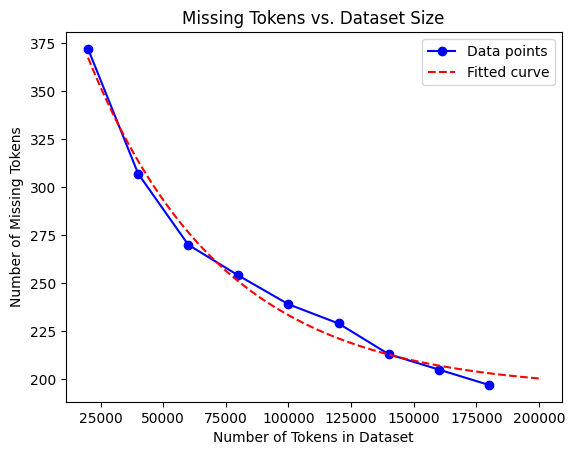

In [ ]:
# 20000 tokens total - Found tokens: 765 (67%), Missing tokens: 372 (33%)
# 40000 tokens total - Found tokens: 830 (73%), Missing tokens: 307 (27%)
# 60000 tokens total - Found tokens: 867 (76%), Missing tokens: 270 (24%)
# 80000 tokens total - Found tokens: 883 (78%), Missing tokens: 254 (22%)
# 100000 tokens total - Found tokens: 898 (79%), Missing tokens: 239 (21%)
# 120000 tokens total - Found tokens: 908 (80%), Missing tokens: 229 (20%)
# 140000 tokens total - Found tokens: 924 (81%), Missing tokens: 213 (19%)
# 160000 tokens total - Found tokens: 932 (82%), Missing tokens: 205 (18%)
# 180000 tokens total - Found tokens: 940 (83%), Missing tokens: 197 (17%)
# 200000 tokens total - Found tokens: 949 (83%), Missing tokens: 188 (17%)
X = [20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000, 200000]
Y = [372, 307, 270, 254, 239, 229, 213, 205, 197, 188]
plt.plot(X, Y, 'bo-', label='Data points')
# let's fit a curve to this (looks like exponential decay)
def model(x, a, b, c):
    return a * np.exp(b * x) + c
popt, pcov = curve_fit(model, X, Y, p0=(400, -0.00001, 150))
a, b, c = popt
print(f"Fitted parameters: a={a}, b={b}, c={c}")
x_fit = np.linspace(20000, 200000, 100)
y_fit = model(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Fitted curve')
plt.xlabel('Number of Tokens in Dataset')
plt.ylabel('Number of Missing Tokens')
plt.title('Missing Tokens vs. Dataset Size')
plt.legend()

In [11]:
missing_tokens

[('dominava', 'dominare', 'VERB', '0bf13569-0487-50c7-bd25-c843b850bd82'),
 ('tegole', 'tegola', 'NOUN', '5596ca0b-0cb5-57ed-a2b5-6447e630993b'),
 ('dimora', 'dimora', 'NOUN', 'cfa8c36a-d6b5-5a93-b229-61379dd9668d'),
 ('disabitata', 'disabitato', 'ADJ', 'd0089561-2d4d-5f15-8ac7-56ba5541fa81'),
 ('hangletoniani',
  'hangletoniano',
  'NOUN',
  '9f33bfa0-067b-52bc-9725-ea1748389f07'),
 ('convenivano', 'convenire', 'VERB', 'e934ff54-9d04-56ef-b6cc-11d85f1d9efc'),
 ('‘sinistra', '‘sinistro', 'ADJ', '6e36b32b-c99e-5dc0-8d4b-a59c46036046'),
 ('fronzoli', 'fronzolo', 'NOUN', 'ae3b3ea1-497e-5d5e-8a33-5d56fd9d96df'),
 ('radunato', 'radunare', 'VERB', '3f603e81-3760-53da-a886-e8ba08460e8f'),
 ('stesi', 'stessere', 'VERB', '95e7b007-dd05-5a53-b0da-b18edb1b6d7f'),
 ('spalancati', 'spalancato', 'ADJ', 'c959f2fe-4067-505e-b154-485898d76249'),
 ('crogiolò', 'crogiolare', 'VERB', 'af5bb1c8-071d-5ac9-9566-c97f78915508'),
 ('atterrita', 'atterrito', 'ADJ', 'd3a74384-f358-5e21-8c01-c32929f6b719'),
 ('mal

In [12]:
missing_groups = []
found_groups = []
temp = hp_df.drop_duplicates(subset=['group_hash'])
for i, row in temp.iterrows():
    group_match_df = df[df['group_hash'] == row['group_hash']]
    if len(group_match_df) == 0:
        missing_groups.append((row['text'], row['lemma'], row['pos'], row['group_hash']))
    else:
        found_groups.append((row['text'], row['lemma'], row['pos'], row['group_hash']))
fg = len(found_groups)
mg = len(missing_groups)
tg = fg + mg
print(f"Found groups: {fg} ({fg/tg:.0%}), Missing groups: {mg} ({mg/tg:.0%})")

Found groups: 790 (90%), Missing groups: 92 (10%)


Fitted parameters: a=176.70877800833267, b=-2.6184321257255785e-05, c=101.727778434149


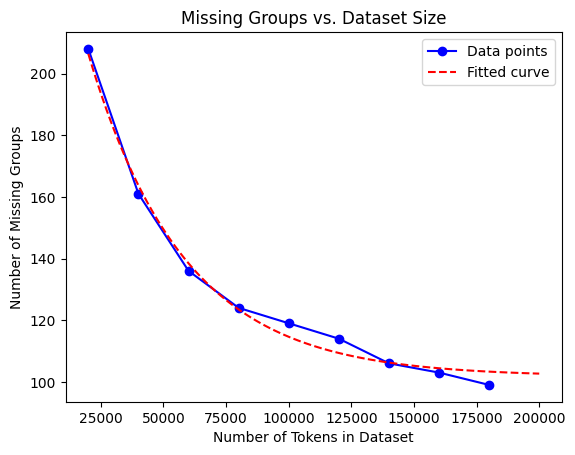

In [ ]:
# 20000 tokens total - Found groups: 674 (76%), Missing groups: 208 (24%)
# 40000 tokens total - Found groups: 721 (82%), Missing groups: 161 (18%)
# 60000 tokens total - Found groups: 746 (85%), Missing groups: 136 (15%)
# 80000 tokens total - Found groups: 758 (86%), Missing groups: 124 (14%)
# 100000 tokens total - Found groups: 763 (87%), Missing groups: 119 (13%)
# 120000 tokens total - Found groups: 768 (87%), Missing groups: 114 (13%)
# 140000 tokens total - Found groups: 776 (88%), Missing groups: 106 (12%)
# 160000 tokens total - Found groups: 779 (88%), Missing groups: 103 (12%)
# 180000 tokens total - Found groups: 783 (89%), Missing groups: 99 (11%)
# 200000 tokens total - Found groups: 790 (90%), Missing groups: 92 (10%)
X = [20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000]
Y = [208, 161, 136, 124, 119, 114, 106, 103, 99]
plt.figure()
plt.plot(X, Y, 'bo-', label='Data points')
# let's fit a curve to this (looks like exponential decay)
def model(x, a, b, c):
    return a * np.exp(b * x) + c
popt, pcov = curve_fit(model, X, Y, p0=(300, -0.00001, 80))
a, b, c = popt
print(f"Fitted parameters: a={a}, b={b}, c={c}")
x_fit = np.linspace(20000, 200000, 100)
y_fit = model(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Fitted curve')
plt.xlabel('Number of Tokens in Dataset')
plt.ylabel('Number of Missing Groups')
plt.title('Missing Groups vs. Dataset Size')
plt.legend()

In [14]:
missing_groups

[('tegole', 'tegola', 'NOUN', '48e1d3b6-725a-5717-9b88-cddc5f95d007'),
 ('dimora', 'dimora', 'NOUN', '17cc9dbe-d078-58d7-9997-6fa85a5aefd0'),
 ('disabitata', 'disabitato', 'ADJ', '4a942872-4507-5840-a197-18645adfa32f'),
 ('hangletoniani',
  'hangletoniano',
  'NOUN',
  'af3bbd43-76a0-5fab-855d-16406371843e'),
 ('‘sinistra', '‘sinistro', 'ADJ', '8efdc643-bf63-5f63-bf69-67ac5aba2c67'),
 ('fronzoli', 'fronzolo', 'NOUN', 'e5c58823-c48b-5b01-a8df-0b66b9f0afbd'),
 ('spalancati', 'spalancato', 'ADJ', '65d256f1-f787-5864-9f2a-a5e91a76137d'),
 ('malcelata', 'malcelato', 'ADJ', '65e8c4df-6a1c-5a8c-9bed-2d9c6005c5d8'),
 ('addolorato', 'addolorare', 'VERB', 'cc249672-875d-5cb9-ae21-371fa869a767'),
 ('snob', 'snob', 'ADJ', '85aab8e4-9e0e-563f-95df-1589e31063c0'),
 ('malridotto', 'malridotto', 'ADJ', 'cb21f710-dcb3-5b14-ade2-ae3c9bd2c414'),
 ('strano', 'strano', 'NOUN', 'e32ca3c5-698b-5d54-a207-dc5dc5153a68'),
 ('sherry', 'sherry', 'NOUN', 'bf97efdf-cb73-53d1-beef-7d919015af3e'),
 ('lui...', 'lui...